<a href="https://colab.research.google.com/github/100522128/g81_P2_03_Aprendizaje_Automatico/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 2 - Determinacion Grupos de Estrellas
**Miembros del grupo:**

Christian Cano -> 100522320

Adrián Curell -> 100522128

[Repositorio de github](https://github.com/100522128/g81_P2_03_Aprendizaje_Automatico.git)

##1 Visualización de los datos

###1.1 Carga del dataset

Cargamos el archivo “starts_data.csv" usando pandas

In [1]:
import pandas as pd
from google.colab import files
archivos = files.upload()
df=pd.read_csv("stars_data.csv")

Saving stars_data.csv to stars_data.csv


###1.2 Tipos de variables

Ahora clasificamos las variables segun su tipo

In [2]:
print(df.dtypes.values)

[dtype('int64') dtype('float64') dtype('float64') dtype('float64')
 dtype('O') dtype('O')]


Como podemos ver todas son o int64/float64 o Object por lo que podemos hacer un clasificador automático que las separe en numéricas (int64/float64) o no numéricas (Object), que se dividirá en categóricas o ordinales.

**En este caso todas serán ordinales.*

Para realizarlo haremos:

1. Dividir las variables en numéricas o no numéricas según su dtype utilizando la función select_dtypes.

2. De las no numéricas sacamos con unique los distintos valores que tienen y con nunique el numero total.

3. Creamos una lista para el tipo (numéricas o ordinales).

4. Recorrer el dataframe con un bucle y rellenando estas listas con los datos de las variables.

5. Crear un dataframe donde introduzcamos los datos de estas listas juntos al nombre y dtype de cada variable.

In [3]:
import numpy as np

# Clasificación automática de variables
variables_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
variables_no_numericas = df.select_dtypes(include=['object']).columns.tolist()

N_unique = []
Valores = []

for i in variables_no_numericas:
  N_unique.append(df[i].nunique())
  Valores.append(df[i].unique())

cardinalidad = pd.DataFrame({
    'Variable': variables_no_numericas,
    'N_unique': N_unique,
    'Valores': Valores
})
print(cardinalidad[['Variable', 'N_unique', 'Valores']].to_string(index=False))

variables_ordinales = []
variables_ordinales = variables_no_numericas.copy()

# Imprimimos la clasificación
print('\n=== Variables NUMÉRICAS ===')
print(variables_numericas)

print('\n=== Variables ORDINALES ===')
print(variables_ordinales)

# Creamos listas vacías donde almacenar los tipos y roles de cada variable
lista_tipo = []

# Recorrer columnas
for c in df.columns:
  # Tipo (Numérica o Ordinal)
  if c in variables_numericas:
    lista_tipo.append('Numérica')
  else:
    lista_tipo.append('Ordinal')


# Crear DataFrame final
resumen_tipos = pd.DataFrame({
    'Variable': df.columns,
    'Dtype': df.dtypes.values,
    'Tipo': lista_tipo,
})

print('\n', resumen_tipos.to_string(index=True))

      Variable  N_unique                                                                                                                                                                                       Valores
         Color        17 [Red, Blue White, White, Yellowish White, Blue white, Pale yellow orange, Blue, Blue-white, Whitish, yellow-white, Orange, White-Yellow, white, yellowish, Yellowish, Orange-Red, Blue-White]
Spectral_Class         7                                                                                                                                                                         [M, B, A, F, O, K, G]

=== Variables NUMÉRICAS ===
['Temperature', 'L', 'R', 'A_M']

=== Variables ORDINALES ===
['Color', 'Spectral_Class']

          Variable    Dtype      Tipo
0     Temperature    int64  Numérica
1               L  float64  Numérica
2               R  float64  Numérica
3             A_M  float64  Numérica
4           Color   object   Ordinal
5  Spectral_

Vemos que son variables ordinales Color y Spectral_Class, siendo el resto variables numericas

###1.3 Valores faltantes

Ahora comprobamos si hay valores faltantes en alguna variable

In [4]:
faltan = pd.DataFrame({
    'Variable': df.columns,
    'Valores faltantes': df.isnull().sum().values,
    '% faltantes': (df.isnull().mean() * 100).round(2).values
})
faltan = faltan[faltan['Valores faltantes'] > 0]

if faltan.empty:
    print('No hay valores faltantes (NaN) en el dataset.')
else:
    print('Variables con valores faltantes:')
    print(faltan.to_string(index=False))

No hay valores faltantes (NaN) en el dataset.


Tras la comprobacion se puede afirmar que no existen valores faltantes por lo que podemos pasar al tratamiento de las variables ordinales directamente

###1.4 Conversión de variables ordinales

En esta etapa del preprocesado, se procedió a la transformación de las variables cualitativas Color y Spectral_Class en magnitudes numéricas mediante un mapeo ordinal. Esta decisión técnica se fundamenta en que ambas variables poseen una jerarquía física intrínseca vinculada a la termodinámica estelar.


Variable Color: Se estableció una escala numérica donde el valor mínimo ($0$) se asignó a las longitudes de onda asociadas a menores temperaturas (colores cálidos como el rojo) y el valor máximo a las estrellas de mayor temperatura superficial (colores de alta energía como el azul).

Variable Spectral_Class: Se aplicó una lógica análoga siguiendo estrictamente la secuencia térmica proporcionada en las directrices de la práctica: (O, B, A, F, G, K, M). En este modelo, las estrellas de tipo M (más frías) representan el extremo inferior de la escala, mientras que las de tipo O (más calientes) definen el extremo superior, preservando así la relación de energía necesaria para el análisis de clustering posterior.

Esta codificación permite que los algoritmos de aprendizaje no supervisado interpreten correctamente la proximidad física entre los diferentes tipos de estrellas, factor que se perdería con otras técnicas como el one-hot encoding.

In [7]:
# 1. Configuración inicial
SEMILLA = 100522320
np.random.seed(SEMILLA)

def transformar_ordinales(X_in):
    X_df = X_in.copy()

    # Diccionarios de mapeo basados en criterios térmicos
    spectral_map = {'o': 6, 'b': 5, 'a': 4, 'f': 3, 'g': 2, 'k': 1, 'm': 0}
    color_map = {
        'red': 0, 'orange red': 1, 'orange': 2, 'pale yellow orange': 3,
        'yellowish': 4, 'yellowish white': 5, 'yellow white': 5,
        'white yellow': 5, 'whitish': 6, 'white': 7, 'blue white': 8, 'blue': 9
    }

    # Limpieza de texto y aplicación de mapeo
    X_df['Spectral_Class'] = X_df['Spectral_Class'].str.lower().map(spectral_map)
    X_df['Color'] = X_df['Color'].str.lower().str.replace('-', ' ').str.strip().map(color_map)

    return X_df

## 2 PCA

Para que sea más sencillo visualizar los datos vamos a usar PCA con los 2 componentes principales. Lo primero será visualizar la varianza explicada acumulada, que como se puede observar, con solo 4 componentes se explica más del 96% de la varianza y con 2 podemos explicar hasta un 85%.

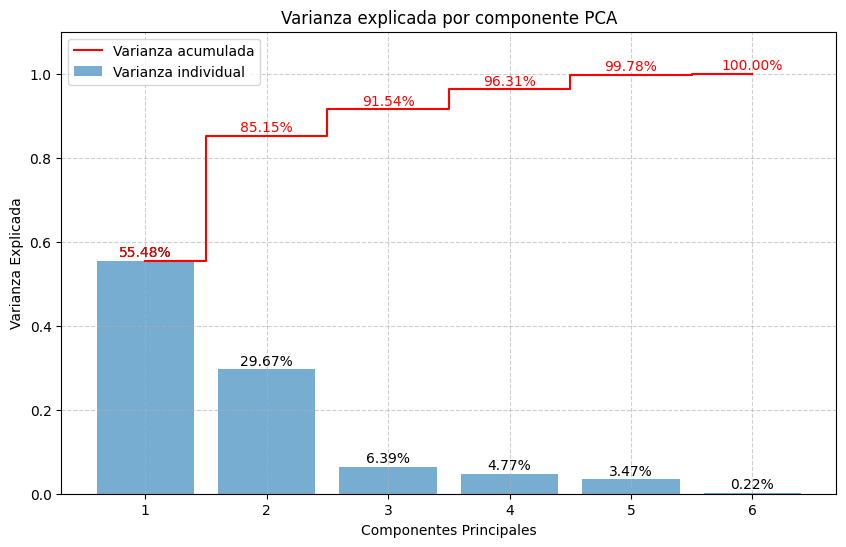

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# Definimos el paso de transformación de las ordinales usando FunctionTransformer
paso_ordinal = FunctionTransformer(transformar_ordinales)

# Creamos el Pipeline de PCA
pipeline_pca = Pipeline([
    ('limpieza_ordinal', paso_ordinal),
    ('escalador', StandardScaler()),
    ('pca', PCA())
])

# Ajustar y transformar
X_pca = pipeline_pca.fit_transform(df)
pca = pipeline_pca.named_steps['pca']

# Varianza explicada y acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot de Varianza Explicada y Acumulada
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Varianza acumulada', color='red')

# Añadir valores exactos
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
    plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza explicada por componente PCA')
plt.legend(loc='best')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Ahora, nos quedaremos con los 2 componentes más importantes, como explica el enunciado:

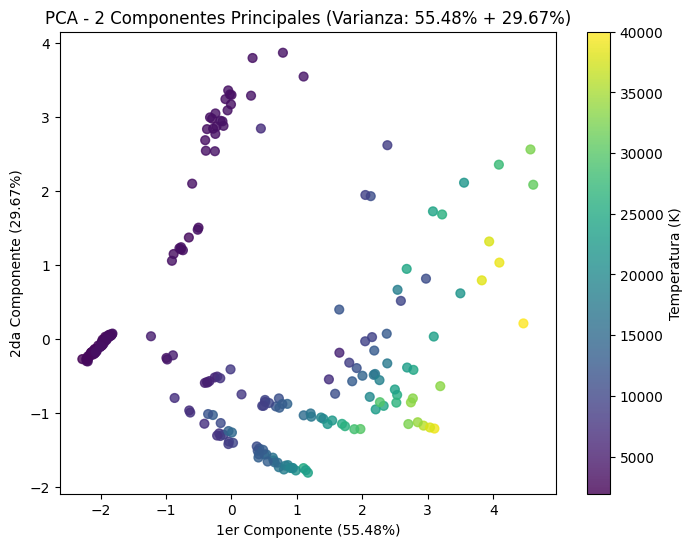

In [23]:
# Creamos el Pipeline de PCA
pipeline_pca = Pipeline([
    ('limpieza_ordinal', paso_ordinal),
    ('escalador', StandardScaler()),
    ('pca', PCA(n_components=2))
])

# Ajustar y transformar
X_pca = pipeline_pca.fit_transform(df)
pca = pipeline_pca.named_steps['pca']

# Visualizar
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Temperature'], s=40, cmap='viridis', alpha=0.8)
plt.title('PCA - 2 Componentes Principales (Varianza: {:.2%} + {:.2%})'.format(explained_variance[0], explained_variance[1]))
plt.xlabel('1er Componente ({:.2%})'.format(explained_variance[0]))
plt.ylabel('2da Componente ({:.2%})'.format(explained_variance[1]))
plt.colorbar(label='Temperatura (K)')
plt.show()